<a href="https://colab.research.google.com/github/un1u3/ml-labs/blob/main/Deep%20Learning/Pytorch/3_Neural_Netwok.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch




A typical training procedure for a neural network is as follows:

- Define the neural network that has some learnable parameters (or weights)

- Iterate over a dataset of inputs

- Process input through the network

- Compute the loss (how far is the output from being correct)

- Propagate gradients back into the network’s parameters

- Update the weights of the network, typically using a simple update rule: weight = weight - learning_rate * gradient




In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


# define  a simple CNN
class NeuralNet(nn.Module):
  def __init__(self):
    super(NeuralNet, self).__init__()


    # ----Conv layers---
    # first convolutation layer
    # takes 1 input channel (greyscale img) produces 6 output channels
    # each with 5x5 learnable kernal(filter)
    # output size :(N,6,28,28) when input is (N,1,32,32)
    self.conv1 = nn.Conv2d(1,6,5)

    # Second convolutional layer:
    # Takes 6 input channels (from conv1), produces 16 output channels,
    # each with a 5x5 kernel.
    # Output size: (N, 16, 10, 10)
    self.conv2 = nn.Conv2d(6,16,5)

    # ------Fully connected linears layers
    # after the conv + pooling layers, the feature maps will have
    # dimensions (16,5,5) i.e 16*5*5 = 400 features per image
    self.fc1 = nn.Linear(16*5*5,120)

    # next fully connected layer redudes from 120 to 84 features
    self.fc2 = nn.Linear(120,84)

    # final output layer :maps 84 neurones to 10 classes(digits 0-9)
    self.fc3 = nn.Linear(84,10)



# defines how data flows through the network
  def forward(self,input):
    # apply first convolutuon , then ReLu activation
    # ReLU(x) = max(0,x) introduces non-linearity
    c1 = F.relu(self.conv1(input))

    # Apply 2x2 max pooling to reduce spatial size(downsampling)
    s2 = F.max_pool2d(c1,(2,2))

    # second convolution + ReLU
    c3 = F.relu(self.conv2(s2))

    # Another 2x2 max pooling
    s4 = F.max_pool2d(c3,2)

    # flatten the features maps into a single vector per image
    s4 = torch.flatten(s4,1)

    # first fully conneceted  layer + ReLU
    f5 = F.relu(self.fc1(s4))


    # second fully connected layer + ReLU
    f6 = F.relu(self.fc2(f5))
    # final output layer (no activation here - handled later by loss func)

    output = self.fc3(f6)
    #  The raw outputs (logits) are returned.
    #In classification tasks, we usually pass these through nn.CrossEntropyLoss,
    # which internally applies softmax for probability interpretation.

    return output

net = NeuralNet()
print(net)

NeuralNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


you feed in a 32×32 grayscale image:

1. Conv1:
Produces 6 feature maps of size 28×28 → detects local edges/patterns.

2. MaxPool2d:
Reduces each map to 14×14 → keeps strong features, discards detail.

3. Conv2:
Learns more abstract features (e.g., corners, textures).
Output: 16 maps of size 10×10.

4. MaxPool2d:
Reduces to 5×5 maps → now 16×5×5 features per image.

5. Flatten:
Converts that into a 1D vector of length 400.

6. fc1 → fc2 → fc3:
Classical dense layers doing nonlinear classification → final 10 outputs.

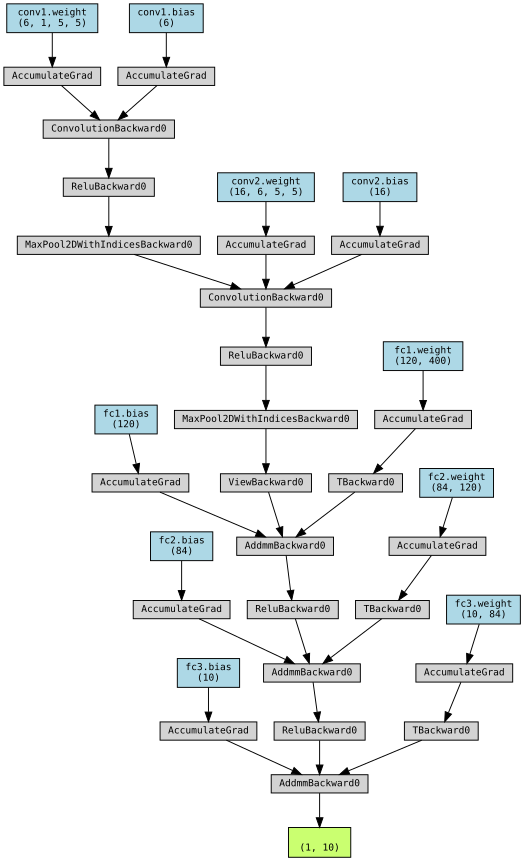

In [ ]:
from torchviz import make_dot
x = torch.randn(1, 1, 32, 32)
y = net(x)

# Create a computation graph
dot = make_dot(y, params=dict(net.named_parameters()))

# Visualize inline (in Jupyter)
dot

In [ ]:
print(net)

NeuralNet(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [ ]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

10
torch.Size([6, 1, 5, 5])


In [ ]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)

tensor([[-0.0547,  0.1128, -0.0561,  0.0671, -0.0343, -0.0948, -0.0350, -0.1222,
         -0.1089,  0.0740]], grad_fn=<AddmmBackward0>)
